In [1]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import matplotlib.pyplot as plt

In [ ]:
!wget -q -nc https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task 

In [ ]:
model_path="face_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = vision.FaceLandmarker
FaceLandmarkerOptions = vision.FaceLandmarkerOptions
FaceLandmarkerResult = vision.FaceLandmarkerResult

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="face_landmarker.task"),
    running_mode=vision.RunningMode.IMAGE)

img = mp.Image(mp.ImageFormat.SRGB, cv2.imread("../pictures/google_ceo.webp"))

with FaceLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(img)

W0000 00:00:1773604031.648594   59788 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1773604031.653648   59790 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773604031.666630   59800 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [14]:
result

FaceLandmarkerResult(face_landmarks=[[NormalizedLandmark(x=0.6609256267547607, y=0.5303449034690857, z=-0.033009469509124756, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6625140309333801, y=0.4613555073738098, z=-0.06623289734125137, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6611615419387817, y=0.4802485704421997, z=-0.034313179552555084, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.650251567363739, y=0.39444637298583984, z=-0.05109495297074318, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6624795198440552, y=0.4407317042350769, z=-0.07069683074951172, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6617401242256165, y=0.4136838912963867, z=-0.06615159660577774, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6595267057418823, y=0.34812837839126587, z=-0.03399445861577988, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.5722727179527283, y

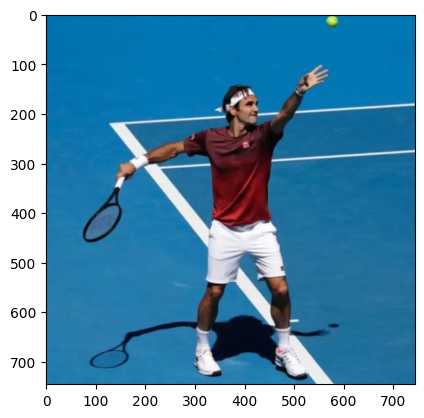

In [11]:
plt.imshow(img.numpy_view())

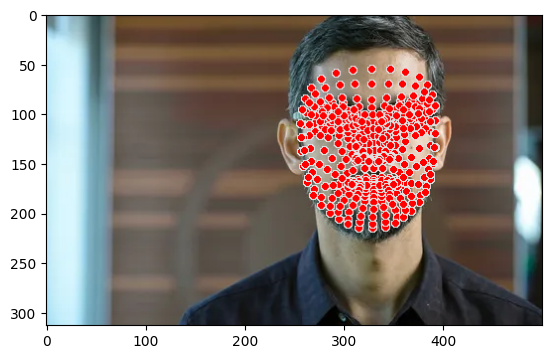

In [20]:
annotated = img.numpy_view().copy()
vision.drawing_utils.draw_landmarks(annotated, result.face_landmarks[0])
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))